In [1]:
## Install Gurobi and import core libraries for optimization, data analysis, and visualization.
## Configuration includes pandas, numpy, matplotlib, seaborn, and warning suppression.
!pip install gurobipy -q

import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
print("Block 1: Environment successfully configured.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 46.2 MB/s eta 0:00:00
Block 1: Environment successfully configured.


In [2]:
# Load demand profiles, plant technical specifications, and time-dependent health costs.
# All datasets are pulled directly from the project's GitHub repository.
url_df_demand = "https://raw.githubusercontent.com/brysonje/Operations_research/refs/heads/main/Datasets/demand_1stjuly2011.csv"
url_df_plant_info = "https://raw.githubusercontent.com/brysonje/Operations_research/refs/heads/main/Datasets/df_plant_info.csv"
url_df_health_cost = "https://raw.githubusercontent.com/brysonje/Operations_research/refs/heads/main/Datasets/df_health_costs.csv"

df_demand = pd.read_csv(url_df_demand)
df_plants = pd.read_csv(url_df_plant_info)
df_health = pd.read_csv(url_df_health_cost)

print("Block 2: Data successfully loaded and ready for processing.")

Block 2: Data successfully loaded and ready for processing.


In [3]:
df_demand.head(2)

,HOUR,LOAD
0,1,11212.28914
1,2,10144.43032


In [4]:
df_plants.head(2)

,Plant,PlantType,FuelType,Capacity,fuel_cost,oper_cost,startup_cost
0,Coal_Bowen,COAL,BIT,2622.37428,36.10,7.384495,147.0
1,Coal_Scherer,COAL,SUB,2860.11000,18.39,7.380880,147.0


In [5]:
df_health.head(2)

,Hour,Coal_Bowen,Coal_Scherer,Coal_JackMcDonough,Other_Coal_Plant,Nuclear_Vogtle,Nuclear_EdwinIHatch,Oil_Plant,Gas_Plant,Hydro_Plant,Biomass_Plant
0,1,18.061545,4.297632,6.845892,0,0,0,0,0,0,0
1,2,15.413092,4.044417,4.317319,0,0,0,0,0,0,0


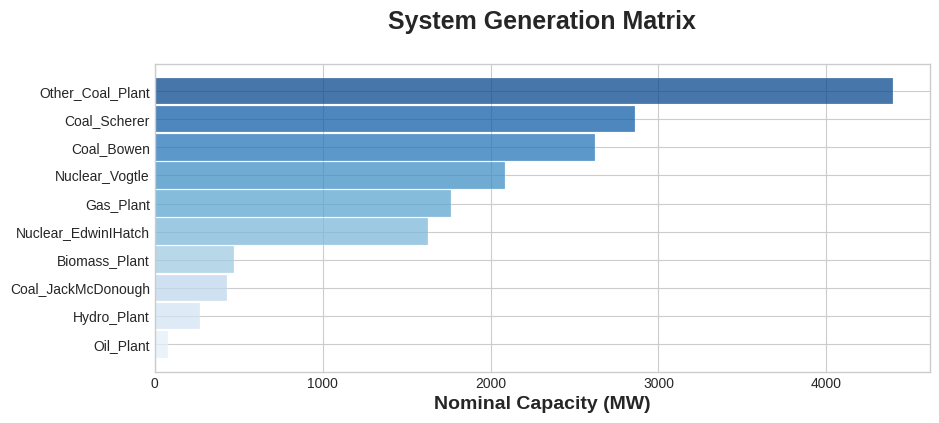

Block 3: Generation Matrix chart successfully rendered.


In [6]:
# Visualize the nominal capacity of each power plant in the system.
# The horizontal bar chart uses a blue color palette to match the study's visual identity.
df_capacity = df_plants[["Plant", "Capacity"]].sort_values(by="Capacity", ascending=True)
colors = sns.color_palette("Blues", 10)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

bars = ax.barh(df_capacity['Plant'], df_capacity['Capacity'], color=colors,
                alpha=0.75, edgecolor='white', linewidth=.2, height=0.95)

ax.set_title('System Generation Matrix', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Nominal Capacity (MW)', fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.show()
print("Block 3: Generation Matrix chart successfully rendered.")

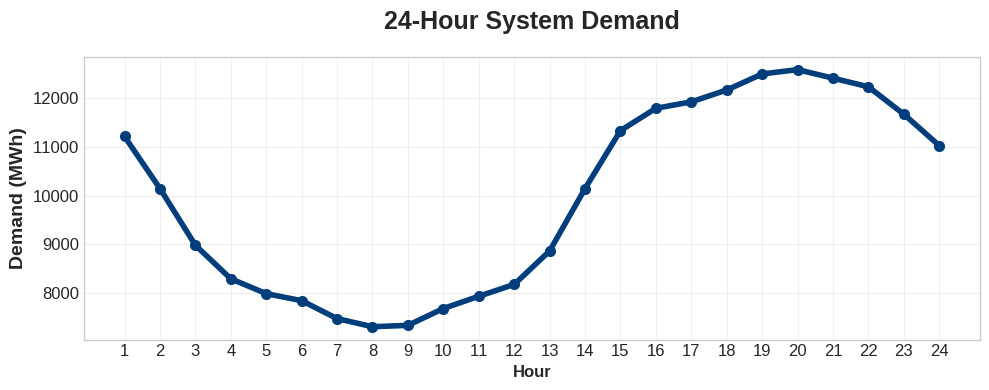

Block 4: Hourly Demand chart successfully rendered.


In [7]:
# Plot the 24-hour network load profile to identify peak demand periods.
# The chart uses a bold blue line with circular markers for high readability.
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 4), dpi=100)

plt.plot(df_demand['HOUR'], df_demand['LOAD'], color='#013e7b', linewidth=4,
         marker='o', markeredgewidth=2, label='Network Demand (Load)')

plt.title('24-Hour System Demand', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Hour', fontsize=12, fontweight='bold')
plt.ylabel('Demand (MWh)', fontsize=14, fontweight='bold')

plt.xticks(df_demand['HOUR'], fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()

plt.show()
print("Block 4: Hourly Demand chart successfully rendered.")

In [8]:
# Automate plant categorization and define technical constraints for ramp limits and stability.
# Nuclear and Coal units follow strict flexibility rules, while Gas/Hydro maintain 100% agility.
nuclear_plants = df_plants[df_plants['PlantType'] == 'NUCLEAR']['Plant'].tolist()
coal_plants = df_plants[df_plants['PlantType'].isin(['COAL', 'OTHER COAL'])]['Plant'].tolist()

def get_ramp_limit(p):
    """Returns the maximum hourly change in generation (Flexibility)."""
    if p in nuclear_plants: return 0.20
    if p in coal_plants: return 0.25
    return 1.0

def get_min_gen_factor(p):
    """Returns the minimum output level required for technical stability."""
    if p in nuclear_plants: return 0.80
    return 0.0

print("Block 5: Operational rules and plant categories successfully defined.")

Block 5: Operational rules and plant categories successfully defined.


In [9]:
# Configure the simulation scenario and define the logic for operational resilience.
# Scenario 3 activates a 2.0x social health penalty during peak hours (17:00-22:00).
scenario = 3  # 1: Baseline, 2: Resilience, 3: Environmental Peak
resilience_factor = 0.85 if scenario >= 2 else 1.0
apply_health_peak = True if scenario == 3 else False

def get_health_multiplier(hour):
    """Returns a 2.0x social cost multiplier during peak hours in Scenario 3."""
    if apply_health_peak and (17 <= hour <= 22):
        return 2.0
    return 1.0

print(f"Block 6: Scenario {scenario} active (Resilience Factor: {resilience_factor}).")

Block 6: Scenario 3 active (Resilience Factor: 0.85).


In [10]:
# Synchronize data sets and map technical specifications into dictionaries for Gurobi.
# Ensures time horizons (1-24) and plant identifiers are perfectly aligned with data keys.
plants_dict = df_plants.set_index('Plant').to_dict('index')
df_demand["HOUR"] = df_demand["HOUR"].astype(int)
demand_dict = df_demand.set_index('HOUR')['LOAD'].to_dict()

plant_names = list(plants_dict.keys())
hours = sorted(demand_dict.keys())
health_costs_dict = df_health.set_index('Hour').to_dict()

print(f"Block 7: Synchronized {len(plant_names)} plants over {len(hours)} periods (Hours {min(hours)}-{max(hours)}).")

Block 7: Synchronized 10 plants over 24 periods (Hours 1-24).


In [11]:
# Initialize the Gurobi model and define Continuous (MW) and Binary (On/Off) variables.
# Continuous variables track generation output, while Binary variables manage unit commitment.
model = gp.Model("Power_Schedule_Twist")

# Continuous: Generation Output (MW) per plant and hour
gen_dict = model.addVars(plant_names, hours, lb=0, name="gen")

# Binary: Operational Status (1: On, 0: Off) per plant and hour
status_dict = model.addVars(plant_names, hours, vtype=GRB.BINARY, name="status")

print(f"Block 8: Model '{model.ModelName}' initialized with {len(gen_dict)} decision variables.")

Restricted license - for non-production use only - expires 2027-11-29
Block 8: Model 'Power_Schedule_Twist' initialized with 240 decision variables.


In [12]:
# Define the multi-objective function: Energy costs, Startup costs, and Social Impact.
# Startup costs are applied to the first hour, while Social costs scale with health multipliers.
cost_energy = gp.quicksum(
    gen_dict[p, t] * plants_dict[p].get('fuel_cost', 0) +
    status_dict[p, t] * plants_dict[p].get('oper_cost', 0)
    for p in plant_names for t in hours
)

cost_startup = gp.quicksum(
    status_dict[p, hours[0]] * plants_dict[p].get('startup_cost', 0)
    for p in plant_names
)

cost_health = gp.quicksum(
    gen_dict[p, t] * (health_costs_dict.get(p, {}).get(t, 0) * get_health_multiplier(t))
    for p in plant_names for t in hours
)

model.setObjective(cost_energy + cost_startup + cost_health, GRB.MINIMIZE)
print("Block 9: Objective function successfully defined and set to Minimize.")

Block 9: Objective function successfully defined and set to Minimize.


In [13]:
# Set the model objective and validate active scenario parameters before adding constraints.
# Ensures the objective function is correctly loaded and all multipliers are active.
model.setObjective(cost_energy + cost_startup + cost_health, GRB.MINIMIZE)

print("--- Optimization Engine Ready ---")
print(f"Active Scenario: {scenario}")
print(f"Resilience Factor: {resilience_factor}")
print(f"Social Health Penalty: {'ENABLED' if apply_health_peak else 'DISABLED'}")
print("Block 10: Objective function loaded. Proceeding to constraints.")

--- Optimization Engine Ready ---
Active Scenario: 3
Resilience Factor: 0.85
Social Health Penalty: ENABLED
Block 10: Objective function loaded. Proceeding to constraints.


In [14]:
# Define core operational constraints: Load balance, Capacity with resilience, and Ramp rates.
# Logic ensures demand is met while respecting plant flexibility and technical minimums.
model.addConstrs((gp.quicksum(gen_dict[p, t] for p in plant_names) >= demand_dict[t]
                  for t in hours), name="Load_Balance")

model.addConstrs((gen_dict[p, t] <= plants_dict[p].get('Capacity', 0) * resilience_factor * status_dict[p, t]
                  for p in plant_names for t in hours), name="Capacity_Resilience_Limit")

for p in plant_names:
    ramp_limit, cap = get_ramp_limit(p), plants_dict[p].get('Capacity', 0)
    for i in range(1, len(hours)):
        t, t_prev = hours[i], hours[i-1]
        model.addConstr(gen_dict[p, t] - gen_dict[p, t_prev] <= cap * ramp_limit, name=f"Ramp_Up_{p}_{t}")
        model.addConstr(gen_dict[p, t_prev] - gen_dict[p, t] <= cap * ramp_limit, name=f"Ramp_Down_{p}_{t}")

model.addConstrs((gen_dict[p, t] >= plants_dict[p].get('Capacity', 0) * get_min_gen_factor(p) * status_dict[p, t]
                  for p in plant_names for t in hours), name="Min_Stable_Gen")

model.update() # Final sync to register all new constraints
print(f"Block 11: {len(model.getConstrs())} constraints synchronized and loaded.")

Block 11: 964 constraints synchronized and loaded.


In [15]:
# Execute the Gurobi optimization engine and diagnose the solution status.
# If infeasible, the model automatically computes the IIS to identify constraint conflicts.
model.optimize()

if model.status == GRB.INFEASIBLE:
    print("\n--- OPTIMIZATION FAILED: MODEL IS INFEASIBLE ---")
    model.computeIIS()
    model.write("conflict.ilp")
    print("IIS computed. Check 'conflict.ilp' to identify the conflicting constraints.")

elif model.status == GRB.OPTIMAL:
    print("\n--- OPTIMIZATION SUCCESSFUL ---")
    print(f"Scenario {scenario} | Total Optimal Cost: ${model.objVal:,.2f}")
    print(f"Resilience Factor: {resilience_factor} | Social Penalty: {apply_health_peak}")

else:
    print(f"\nOptimization ended with status code: {model.status}")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 964 rows, 480 columns and 1928 nonzeros (Min)
Model fingerprint: 0x9e2f4e90
Model has 456 linear objective coefficients
Variable types: 240 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+03]
  Objective range  [5e+00, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 1e+04]

Presolve removed 518 rows and 95 columns
Presolve time: 0.02s
Presolved: 446 rows, 385 columns, 1313 nonzeros
Variable types: 216 continuous, 169 integer (169 binary)
Found heuristic solution: objective 6923707.8949

Root relaxation: objective 5.410034e+06, 141 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth

In [16]:
# Breakdown of costs and energy balance to validate the optimization results.
# Separates Fuel, Operating, Startup, and Social costs for a granular system analysis.
if model.status == GRB.OPTIMAL:
    print("-" * 50)
    print(f"RESULTS FOR SCENARIO {scenario}: OPTIMIZATION SUCCESSFUL")
    print("-" * 50)

    # 1. Cost Components Calculation
    fuel_c = sum(gen_dict[p, t].X * plants_dict[p].get('fuel_cost', 0) for p in plant_names for t in hours)
    oper_c = sum(status_dict[p, t].X * plants_dict[p].get('oper_cost', 0) for p in plant_names for t in hours)
    start_c = sum(status_dict[p, hours[0]].X * plants_dict[p].get('startup_cost', 0) for p in plant_names)
    health_c = sum(gen_dict[p, t].X * (health_costs_dict.get(p, {}).get(t, 0) * get_health_multiplier(t))
                   for p in plant_names for t in hours)

    # --- FINANCIAL SUMMARY TABLE ---
    print(f"{'COST CATEGORY':<30} | {'AMOUNT':>15}")
    print("-" * 50)
    print(f"{'Fuel Variable Costs':<30} | ${fuel_c:>14,.2f}")
    print(f"{'Operating Fixed Costs':<30} | ${oper_c:>14,.2f}")
    print(f"{'Startup Costs (Initial)':<30} | ${start_c:>14,.2f}")
    print(f"{'Social Health Impact':<30} | ${health_c:>14,.2f}")
    print("-" * 50)
    print(f"{'TOTAL SYSTEM COST':<30} | ${model.objVal:>14,.2f}")
    print("-" * 50)

    # 2. Energy Balance Audit
    total_gen, total_dem = sum(gen_dict[p, t].X for p in plant_names for t in hours), sum(demand_dict.values())
    print(f"Total Generation: {total_gen:,.2f} MWh | Total Demand: {total_dem:,.2f} MWh")
    print(f"System Balance Delta: {total_gen - total_dem:,.2f} MWh")
    print("-" * 50)

else:
    print(f"Optimization ended with status: {model.status}. Check constraints or data.")

--------------------------------------------------
RESULTS FOR SCENARIO 3: OPTIMIZATION SUCCESSFUL
--------------------------------------------------
COST CATEGORY                  |          AMOUNT
--------------------------------------------------
Fuel Variable Costs            | $  4,930,238.77
Operating Fixed Costs          | $      1,788.38
Startup Costs (Initial)        | $        510.00
Social Health Impact           | $    477,546.42
--------------------------------------------------
TOTAL SYSTEM COST              | $  5,410,083.58
--------------------------------------------------
Total Generation: 239,001.38 MWh | Total Demand: 239,001.38 MWh
System Balance Delta: 0.00 MWh
--------------------------------------------------


In [17]:
# Extract optimization results into a structured DataFrame for downstream analysis.
# Transforms Gurobi variables (.X) into a pivot table suitable for Heatmaps and Area Charts.
results_data = []
for p in plant_names:
    for t in hours:
        results_data.append({
            'Plant': p,
            'Hour': t,
            'Generation': gen_dict[p, t].X,
            'Status': status_dict[p, t].X,
            'Type': plants_dict[p].get('PlantType', 'Other')
        })

df_results = pd.DataFrame(results_data)

# Create the Generation Matrix (Plants as Rows, Hours as Columns)
pivot_gen = df_results.pivot(index='Plant', columns='Hour', values='Generation')

print(f"Block 14: {len(df_results)} data points extracted. Pivot table ready for visualization.")

Block 14: 240 data points extracted. Pivot table ready for visualization.


Block 15 (Debug): Data aggregation complete.
Plant Types identified in results: ['COAL' 'OTHER COAL' 'NUCLEAR' 'OIL' 'GAS' 'HYDRO' 'BIOMASS']


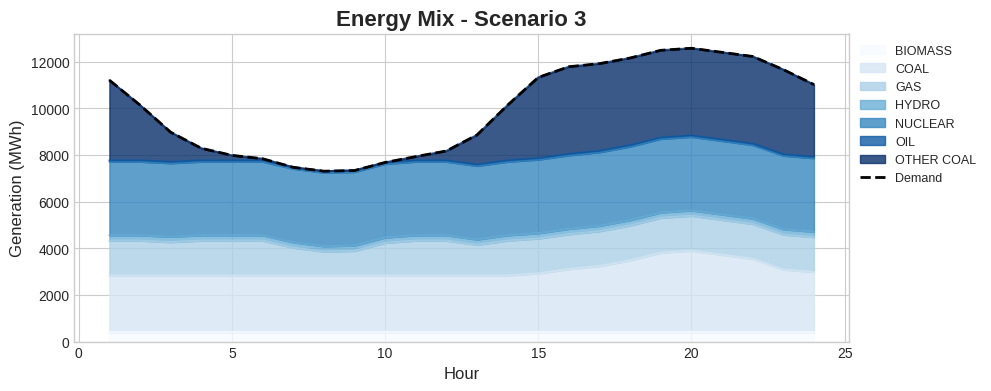

In [18]:
# Reuse the previously extracted results to create an aggregated view by plant type.
# This avoids redundant loops and ensures visual consistency across all verification charts.
df_stack = df_results.groupby(['Hour', 'Type'])['Generation'].sum().unstack().fillna(0)

# --- DEBUG & QUALITY CONTROL OUTPUT ---
print(f"Block 15 (Debug): Data aggregation complete.")
print(f"Plant Types identified in results: {df_results['Type'].unique()}")

if df_results['Generation'].sum() == 0:
    print("WARNING: Total generation is 0. Check optimization status or constraints.")

# --- AREA CHART FOR VISUAL CROSS-CHECK ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# Plotting the stacked energy mix and the demand line for validation
df_stack.plot(kind='area', stacked=True, ax=ax, alpha=0.8, cmap='Blues')
ax.plot(df_stack.index, [demand_dict[t] for t in df_stack.index],
        color='black', label='Demand', linewidth=2, linestyle='--')

ax.set_title(f"Energy Mix - Scenario {scenario}", fontsize=16, fontweight='bold')
ax.set_xlabel("Hour", fontsize=12)
ax.set_ylabel("Generation (MWh)", fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=9)

plt.show()

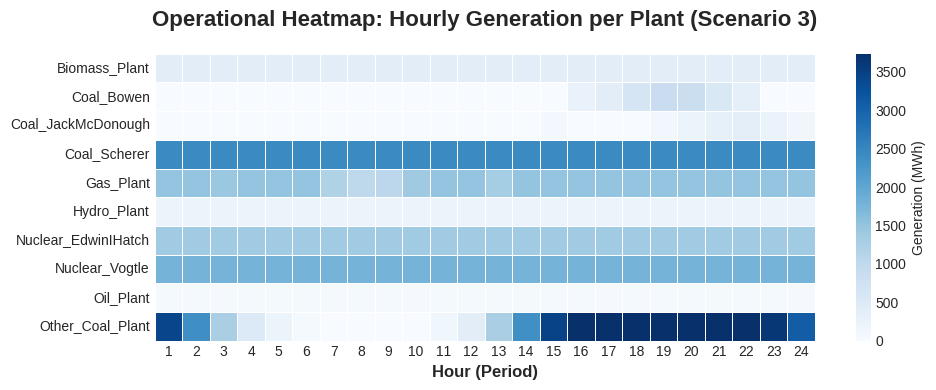

Block 16: Final Heatmap rendered. Darker regions indicate base load operations.


In [19]:
# Visualize the 24-hour generation profile for all power plants in the system.
# The heatmap highlights base load units with constant, dark blue rows, and peaking units with variable blocks.
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# Create the Heatmap using the pre-calculated pivot table from Block 14
# Annot=False is best for large matrix visibility; switch to True to inspect exact MWh.
sns.heatmap(pivot_gen, ax=ax, cmap="Blues", annot=False, linewidths=.5,
            cbar_kws={'label': 'Generation (MWh)'})

# Esthetics, Labels, and Title
ax.set_title(f'Operational Heatmap: Hourly Generation per Plant (Scenario {scenario})',
              fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour (Period)', fontsize=12, fontweight='bold')
ax.set_ylabel('')

# Clean up layout to prevent label cutoff
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()
print(f"Block 16: Final Heatmap rendered. Darker regions indicate base load operations.")

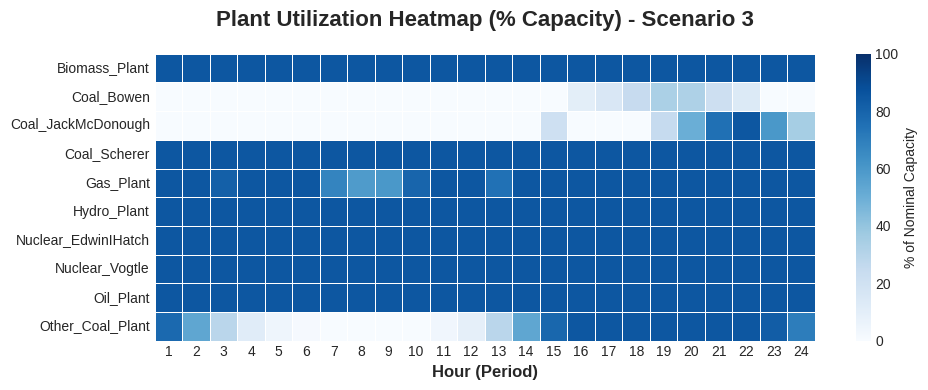

Block 17: Utilization Heatmap generated. Darker shades indicate higher capacity usage.


In [20]:
# Calculate and visualize the percentage of nominal capacity utilized by each plant.
# This heatmap normalizes the effort, showing which units are pushed to their operational limits.
df_results['Utilization_%'] = df_results.apply(
    lambda x: (x['Generation'] / plants_dict[x['Plant']].get('Capacity', 1)) * 100, axis=1
)

# Pivot data for the utilization matrix
pivot_util = df_results.pivot(index='Plant', columns='Hour', values='Utilization_%')

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# Heatmap with a fixed scale (0-100%) to ensure consistency across scenarios
sns.heatmap(pivot_util, ax=ax, cmap="Blues", vmin=0, vmax=100,
            annot=False, fmt=".0f", linewidths=.5,
            cbar_kws={'label': '% of Nominal Capacity'})

ax.set_title(f'Plant Utilization Heatmap (% Capacity) - Scenario {scenario}',
              fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour (Period)', fontsize=12, fontweight='bold')
ax.set_ylabel('')

plt.yticks(rotation=0)
plt.tight_layout()

plt.show()
print("Block 17: Utilization Heatmap generated. Darker shades indicate higher capacity usage.")

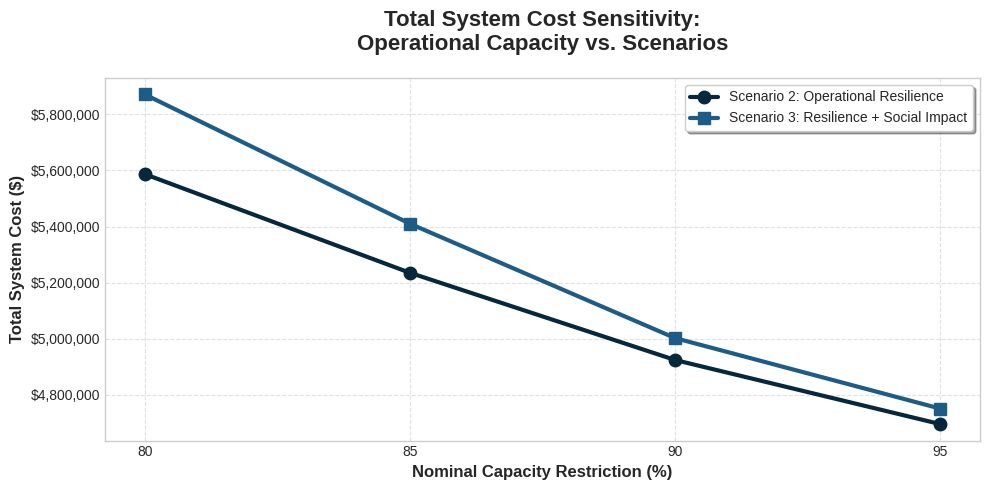

Block 18: Sensitivity chart generated. Analysis of the cost-resilience frontier complete.


In [21]:
# Final sensitivity analysis comparing Total System Costs across scenarios and capacity limits.
# Highlights the economic impact of social health costs and operational resilience constraints.
from matplotlib.ticker import StrMethodFormatter

# 1. Data Definition (Based on the Multi-Scenario Optimization Results)
capacity_pct = [80, 85, 90, 95]
total_cost_s2 = [5586894, 5235148, 4924267, 4695744] # Resilience only
total_cost_s3 = [5870975, 5410082, 5002391, 4750934] # Resilience + Social Health

# 2. Plot Configuration
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

# Scenario 2: Deep Blue (Professional & Steady)
ax.plot(capacity_pct, total_cost_s2, color='#07273c', linewidth=3,
        marker='o', markersize=9, label='Scenario 2: Operational Resilience')

# Scenario 3: Medium Blue (The Social "Twist")
ax.plot(capacity_pct, total_cost_s3, color='#1c5c87', linewidth=3,
        marker='s', markersize=9, label='Scenario 3: Resilience + Social Impact')

# 3. Aesthetics and Formatting
ax.set_title('Total System Cost Sensitivity:\nOperational Capacity vs. Scenarios',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Nominal Capacity Restriction (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total System Cost ($)', fontsize=12, fontweight='bold')

# Ensure X-axis shows the correct percentage steps
ax.set_xticks(capacity_pct)

# Format Y-axis for currency readability (e.g., 5,000,000)
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# 4. Final Touches
ax.legend(fontsize=10, loc='upper right', frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()
print("Block 18: Sensitivity chart generated. Analysis of the cost-resilience frontier complete.")